# Urban Safety — Linear Regression
Tests whether built-environment features (lighting, visibility, connectivity, enclosure) predict street-level crime rate.

**Hypothesis:**  
`safety = (lighting×0.35) + (visibility×0.25) + (connectivity×0.20) + ((1−enclosure)×0.20)`

**Method (Option A):** Features come from OSM. Target (y) comes from real police crime data.  
The regression learns its own coefficients — we then compare them against the hypothesized weights.

## Cell 1 — Imports and config
This cell will need reconfiguring once all different city data has been converged into a single CSV

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import box

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)
ox.settings.requests_timeout = 600

# ── City config ──────────────────────────
CITY_NAME   = 'London'
OSM_PLACE   = 'London Borough of Islington, London, UK'
CRS_METRIC  = 'EPSG:27700'   # British National Grid (meters)
BUFFER_M    = 50             # buffer radius around each segment (meters)
CRIME_CSV   = 'G:\My Drive\AIA - Data Encoding\london_crime_only.csv'  # path to police crime CSV
# ─────────────────────────────────────────────────────────────────────────────

print(f'Config ready — city: {CITY_NAME}, buffer: {BUFFER_M}m, CRS: {CRS_METRIC}')

Config ready — city: London, buffer: 50m, CRS: EPSG:27700


## Cell 2 — Fetch OSM data
Downloads three layers for the configured city: street network, building footprints, and street lamps.
All three are reprojected to the metric CRS so distances are in meters.

In [3]:
# ── 1. Street network (intersection-to-intersection edges + nodes) ───────────
# G is a NetworkX graph object representing the street network of the city.

G = ox.graph_from_place(OSM_PLACE, network_type="walk")
nodes, edges = ox.graph_to_gdfs(G)

# Transforming coordinates to a metric CRSn (coordinate reference system) for accurate distance calculations and buffering.
nodes = nodes.to_crs(CRS_METRIC)
edges = edges.to_crs(CRS_METRIC)

print(f"Street segments : {len(edges):,}")
print(f"Intersection nodes: {len(nodes):,}")

# ── 2. Building footprints ───────────────────────────────────────────────────
buildings_raw = ox.features_from_place(OSM_PLACE, tags={"building": True})
buildings = buildings_raw[buildings_raw.geometry.geom_type == "Polygon"].copy()
buildings = buildings.to_crs(CRS_METRIC)

# Building height: use "height" tag if available, else estimate from "building:levels" (3m/floor)
buildings["height_m"] = pd.to_numeric(buildings.get("height"), errors="coerce")
levels = pd.to_numeric(buildings.get("building:levels"), errors="coerce")
buildings["height_m"] = buildings["height_m"].fillna(levels * 3)
buildings["height_m"] = buildings["height_m"].fillna(buildings["height_m"].median())

print(f"Buildings         : {len(buildings):,}")
print(f"  with height data: {buildings['height_m'].notna().sum():,}")

# ── 3. Street lamps ─────────────────────────────────────────────────────────
lamps_raw = ox.features_from_place(OSM_PLACE, tags={"highway": "street_lamp"})
lamps = lamps_raw[lamps_raw.geometry.geom_type == "Point"].copy()
lamps = lamps.to_crs(CRS_METRIC)

print(f"Street lamps      : {len(lamps):,}")


Street segments : 22,586
Intersection nodes: 8,759
Buildings         : 22,851
  with height data: 22,851
Street lamps      : 282


## Cell 3 — Compute features per segment
For each street segment, we create a rectangular buffer (25m each side, flat ends) 
and compute the 4 features inside it.

In [4]:
# ── Prep: reset edge index so seg_id is a plain integer column ──────────────
edges_df = edges.reset_index()
edges_df['seg_id'] = range(len(edges_df))

# ── Rectangular buffers: 25m each side, flat ends at intersections ──────────
# cap_style=2 means flat (square) ends — gives a true A→B rectangle
buffers_gdf = gpd.GeoDataFrame(
    edges_df[['seg_id', 'u', 'v']],
    geometry=edges_df.geometry.buffer(BUFFER_M, cap_style=2),
    crs=CRS_METRIC
)
buffers_gdf['buffer_area'] = buffers_gdf.geometry.area

# ── Feature 1: Connectivity — (degree_u + degree_v) / 2 ─────────────────────
degree_map = dict(G.degree())
edges_df['connectivity'] = (
    edges_df['u'].map(degree_map) + edges_df['v'].map(degree_map)
) / 2

# ── Feature 2: Lighting — lamppost count per buffer ──────────────────────────
lamp_join = gpd.sjoin(
    lamps[['geometry']],
    buffers_gdf[['seg_id', 'geometry']],
    how='inner', predicate='within'
)
lamp_counts = lamp_join.groupby('seg_id').size().rename('lighting')

# ── Features 3 & 4: Visibility + Enclosure — from buildings ─────────────────
# Clip building footprints to each buffer to get exact overlap area
# (this is the slow step — may take 1-2 min for large areas)
print('Clipping buildings to buffers...')
bldg_clip = gpd.overlay(
    buildings[['geometry', 'height_m']].reset_index(drop=True),
    buffers_gdf[['seg_id', 'geometry']],
    how='intersection'
)
bldg_clip['clipped_area'] = bldg_clip.geometry.area

bldg_agg = bldg_clip.groupby('seg_id').agg(
    building_area=('clipped_area', 'sum'),
    avg_height=('height_m', 'mean')
).reset_index()

# ── Assemble all features into one table ─────────────────────────────────────
features = edges_df[['seg_id', 'u', 'v', 'geometry', 'connectivity']].copy()
features = features.merge(lamp_counts,                       on='seg_id', how='left')
features = features.merge(bldg_agg,                          on='seg_id', how='left')
features = features.merge(buffers_gdf[['seg_id', 'buffer_area']], on='seg_id', how='left')

# Fill zero for segments with no lamps or no buildings in range
features['lighting']      = features['lighting'].fillna(0)
features['building_area'] = features['building_area'].fillna(0)
features['avg_height']    = features['avg_height'].fillna(0)

# ── Compute final formula values ──────────────────────────────────────────────
features['visibility'] = (1 - features['building_area'] / features['buffer_area']).clip(0, 1)
features['enclosure']  = (features['building_area'] * features['avg_height'] / features['buffer_area']).clip(0)

print(f'Segments with features: {len(features):,}')
features[['connectivity', 'lighting', 'visibility', 'enclosure']].describe()


Clipping buildings to buffers...
Segments with features: 22,586


,connectivity,lighting,visibility,enclosure
count,22586.000,22586.000,22586.000,22586.000
mean,5.967,0.089,0.754,2.551
std,1.053,0.536,0.174,2.435
min,3.000,0.000,0.000,0.000
25%,6.000,0.000,0.662,1.207
50%,6.000,0.000,0.764,2.232
75%,7.000,0.000,0.873,3.246
max,9.000,10.000,1.000,36.316


## Cell 4 — Load crime data and count per segment
Crime events are points. We count how many fall inside each segment's rectangle — that becomes **y**.

In [8]:
# ── Load crime CSV ────────────────────────────────────────────────────────────
crime_df = pd.read_csv(CRIME_CSV)
crime_df = crime_df.dropna(subset=['latitude', 'longitude'])

# Convert to GeoDataFrame (WGS84 first, then reproject to match our segments)
crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df.longitude, crime_df.latitude),
    crs='EPSG:4326'
).to_crs(CRS_METRIC)

print(f'Crime events loaded: {len(crime_gdf):,}')

# ── Count crimes per segment rectangle ───────────────────────────────────────
crime_join = gpd.sjoin(
    crime_gdf[['geometry']],
    buffers_gdf[['seg_id', 'geometry']],
    how='inner', predicate='within'
)
crime_counts = crime_join.groupby('seg_id').size().rename('crime_count')

# Merge into features table; segments with zero crimes get 0
features = features.merge(crime_counts, on='seg_id', how='left')
features['crime_count'] = features['crime_count'].fillna(0).astype(int)

print(f'Segments with at least one crime : {(features.crime_count > 0).sum():,}')
print(f'Segments with zero crimes        : {(features.crime_count == 0).sum():,}')
print(f'Mean crimes per segment          : {features.crime_count.mean():.2f}')
features['crime_count'].describe()


Crime events loaded: 83,608
Segments with at least one crime : 6,616
Segments with zero crimes        : 15,970
Mean crimes per segment          : 25.19


count   22586.000
mean       25.187
std        71.491
min         0.000
25%         0.000
50%         0.000
75%        21.000
max      1412.000
Name: crime_count, dtype: float64

## Cell 5 — Regression
Define X and y, scale, split, train, evaluate.

Train size: (18068, 4) segments, columns
Test size : (4518, 4) segments, columns
R² train : 0.035
R² test  : 0.036
Coefficients:
     feature  learned_coef  hypothesized
    lighting         3.804         0.350
  visibility       -15.797         0.250
connectivity         1.860         0.200
   enclosure        -5.010         0.200


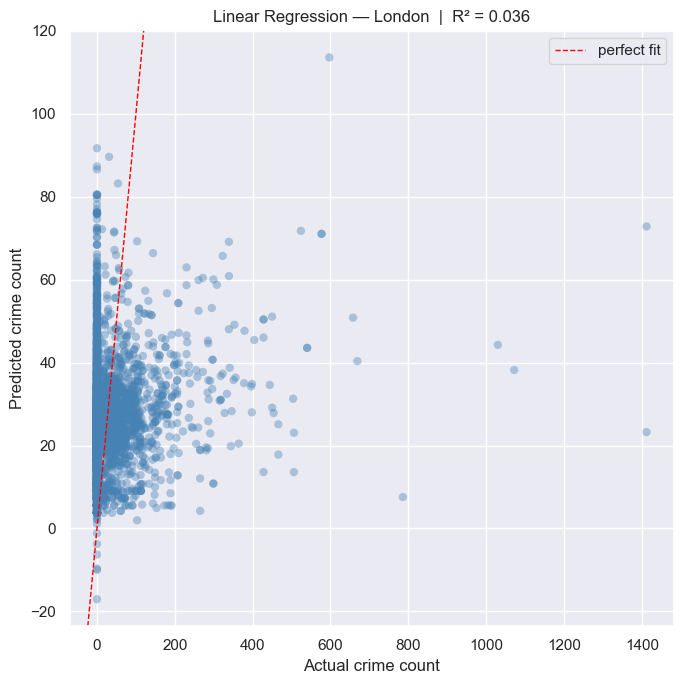

In [ ]:
# ── Define X (features) and y (target) ───────────────────────────────────────
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure']

X = features[FEATURE_COLS].values
y = features['crime_count'].values

# ── Scale X ──────────────────────────────────────────────────────────────────
# StandardScaler converts everything to the same scale: 0 is the average, +1 means one standard deviation above average, -1 means one below. Now the model can compare them fairly.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train / test split (80/20) ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape} segments, columns')
print(f'Test size : {X_test.shape} segments, columns')

# ── Train model ──────────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Evaluate ─────────────────────────────────────────────────────────────────
#TRAIN =  how well the model fits the data it learned from
r2_train = model.score(X_train, y_train)
#TEST = how well the model predicts new data it hasn't seen before
r2_test  = model.score(X_test,  y_test)

print(f'R² train : {r2_train:.3f}')
print(f'R² test  : {r2_test:.3f}')

# ── Coefficients vs hypothesized weights ─────────────────────────────────────
hypothesized = [0.35, 0.25, 0.20, 0.20]
coef_df = pd.DataFrame({
    'feature'     : FEATURE_COLS,
    'learned_coef': model.coef_,
    'hypothesized': hypothesized
})
print('Coefficients:')
print(coef_df.to_string(index=False))

# ── Plot: predicted vs actual ─────────────────────────────────────────────────
y_pred = model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue')
plt.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1, label='perfect fit')
plt.xlabel('Actual crime count')
plt.ylabel('Predicted crime count')
plt.title(f'Linear Regression — {CITY_NAME}  |  R² = {r2_test:.3f}')
plt.legend()
plt.tight_layout()
plt.show()
